# Demo Forced Alignment using Wav2vec2 as acoustic model
___
Sourced from torchaudio demo [FORCED ALIGNMENT WITH WAV2VEC2](https://pytorch.org/audio/main/tutorials/forced_alignment_tutorial.html#) by Moto Hira
 

In [51]:
import torch
import torchaudio
import torchaudio.transforms as T


print(torch.__version__)
print(torchaudio.__version__)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

1.11.0
0.11.0
cuda


In [29]:
%matplotlib inline

from dataclasses import dataclass

import IPython
import matplotlib
import matplotlib.pyplot as plt

import re
from tqdm import tqdm
from pathlib import Path
matplotlib.rcParams["figure.figsize"] = [16.0, 4.8]

torch.random.manual_seed(0)

## Get example file

In [49]:
waveform.dtype

torch.float32

In [4]:
cv_path = Path('/scratch2/weka/mcdermott/imgriff/datasets/commonvoice_9/en/clips')

In [87]:
file  = cv_path / 'common_voice_en_28322365'

SPEECH_FILE = file.with_suffix('.mp3')


In [88]:
metadata = torchaudio.info(SPEECH_FILE)
print(metadata)

AudioMetaData(sample_rate=32000, num_frames=279936, num_channels=1, bits_per_sample=0, encoding=MP3)


## Get pretrained wav2vec2 model

In [80]:
bundle = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H
model = bundle.get_model().to(device)
labels = bundle.get_labels()

In [89]:
bundle._sample_rate

16000

In [79]:
resample_rate = bundle._sample_rate
resampler = T.Resample(metadata.sample_rate, resample_rate, dtype=torch.float32)

In [140]:
with torch.inference_mode(): 
        waveform, wav_sr = torchaudio.load(SPEECH_FILE)
        waveform = resampler(waveform)
        emissions, _ = model(waveform.to(device))

        emissions = torch.log_softmax(emissions, dim=-1)

emission = emissions[0].cpu().detach()

('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')


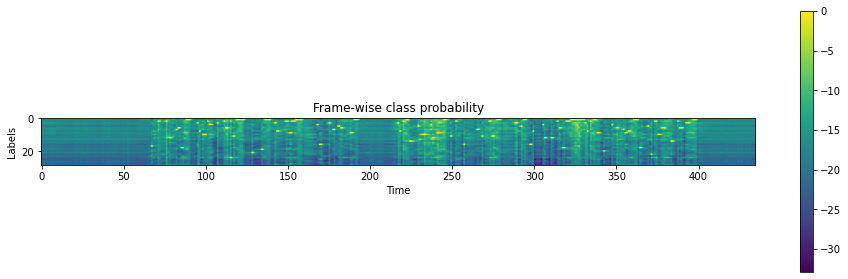

In [141]:
print(labels)
plt.imshow(emission.T)
plt.colorbar()
plt.title("Frame-wise class probability")
plt.xlabel("Time")
plt.ylabel("Labels")
plt.show()

## Get trellis

In [92]:
### Process transcript to match expected format

transcript = open(file.with_suffix('.txt'), 'r').read()
transcript = '|'.join([re.sub("[^\w\d'\s]+",'', word) for word in transcript.upper().split(' ')])
transcript

'FEELING|THREATENED|BY|THESE|ACTIONS|THE|MOROS|DECIDED|TO|CHALLENGE|THE|SPANISH|GOVERNMENT'

In [142]:
dictionary = {c: i for i, c in enumerate(labels)}

tokens = [dictionary[c] for c in transcript]
print(list(zip(transcript, tokens)))

# gets character-level trellis
def get_trellis(emission, tokens, blank_id=0):
    num_frame = emission.size(0)
    num_tokens = len(tokens)

    # Trellis has extra diemsions for both time axis and tokens.
    # The extra dim for tokens represents <SoS> (start-of-sentence)
    # The extra dim for time axis is for simplification of the code.
    trellis = torch.empty((num_frame + 1, num_tokens + 1))
    trellis[0, 0] = 0
    trellis[1:, 0] = torch.cumsum(emission[:, 0], 0)
    trellis[0, -num_tokens:] = -float("inf")
    trellis[-num_tokens:, 0] = float("inf")

    for t in range(num_frame):
        trellis[t + 1, 1:] = torch.maximum(
            # Score for staying at the same token
            trellis[t, 1:] + emission[t, blank_id],
            # Score for changing to the next token
            trellis[t, :-1] + emission[t, tokens],
        )
    return trellis


trellis = get_trellis(emission, tokens)


[('F', 17), ('E', 2), ('E', 2), ('L', 12), ('I', 7), ('N', 6), ('G', 18), ('|', 1), ('T', 3), ('H', 8), ('R', 10), ('E', 2), ('A', 4), ('T', 3), ('E', 2), ('N', 6), ('E', 2), ('D', 11), ('|', 1), ('B', 21), ('Y', 19), ('|', 1), ('T', 3), ('H', 8), ('E', 2), ('S', 9), ('E', 2), ('|', 1), ('A', 4), ('C', 16), ('T', 3), ('I', 7), ('O', 5), ('N', 6), ('S', 9), ('|', 1), ('T', 3), ('H', 8), ('E', 2), ('|', 1), ('M', 14), ('O', 5), ('R', 10), ('O', 5), ('S', 9), ('|', 1), ('D', 11), ('E', 2), ('C', 16), ('I', 7), ('D', 11), ('E', 2), ('D', 11), ('|', 1), ('T', 3), ('O', 5), ('|', 1), ('C', 16), ('H', 8), ('A', 4), ('L', 12), ('L', 12), ('E', 2), ('N', 6), ('G', 18), ('E', 2), ('|', 1), ('T', 3), ('H', 8), ('E', 2), ('|', 1), ('S', 9), ('P', 20), ('A', 4), ('N', 6), ('I', 7), ('S', 9), ('H', 8), ('|', 1), ('G', 18), ('O', 5), ('V', 22), ('E', 2), ('R', 10), ('N', 6), ('M', 14), ('E', 2), ('N', 6), ('T', 3)]


In [126]:
@dataclass
class Point:
    token_index: int
    time_index: int
    score: float


def backtrack(trellis, emission, tokens, blank_id=0):
    # Note:
    # j and t are indices for trellis, which has extra dimensions
    # for time and tokens at the beginning.
    # When referring to time frame index `T` in trellis,
    # the corresponding index in emission is `T-1`.
    # Similarly, when referring to token index `J` in trellis,
    # the corresponding index in transcript is `J-1`.
    j = trellis.size(1) - 1
    t_start = torch.argmax(trellis[:, j]).item()

    path = []
    for t in range(t_start, 0, -1):
        # 1. Figure out if the current position was stay or change
        # Note (again):
        # `emission[J-1]` is the emission at time frame `J` of trellis dimension.
        # Score for token staying the same from time frame J-1 to T.
        stayed = trellis[t - 1, j] + emission[t - 1, blank_id]
        # Score for token changing from C-1 at T-1 to J at T.
        changed = trellis[t - 1, j - 1] + emission[t - 1, tokens[j - 1]]

        # 2. Store the path with frame-wise probability.
        prob = emission[t - 1, tokens[j - 1] if changed > stayed else 0].exp().item()
        # Return token index and time index in non-trellis coordinate.
        path.append(Point(j - 1, t - 1, prob))

        # 3. Update the token
        if changed > stayed:
            j -= 1
            if j == 0:
                break
    else:
        raise ValueError("Failed to align")
    return path[::-1]


path = backtrack(trellis, emission, tokens)
# path_list = [backtrack(trellis, emission, tokens) for trellis,emission in zip(trellis_list, emission_list)]
for p in path:
    print(p)

In [214]:
# Merge the labels
@dataclass
class Segment:
    label: str
    start: int
    end: int
    score: float

    def __repr__(self):
        return f"{self.label}\t({self.score:4.2f}): [{self.start:5d}, {self.end:5d})"

    @property
    def length(self):
        return self.end - self.start

@dataclass
class Alignment:
    label: str
    start: int
    end: int
    score: float

    def __repr__(self):
        return f"{self.label}\t({self.score:4.2f}): [{self.start:.4f}, {self.end:.4f})"

    @property
    def length(self):
        return self.end - self.start


def merge_repeats(path):
    i1, i2 = 0, 0
    segments = []
    while i1 < len(path):
        while i2 < len(path) and path[i1].token_index == path[i2].token_index:
            i2 += 1
        score = sum(path[k].score for k in range(i1, i2)) / (i2 - i1)
        segments.append(
            Segment(
                transcript[path[i1].token_index],
                path[i1].time_index,
                path[i2 - 1].time_index + 1,
                score,
            )
        )
        i1 = i2
    return segments


# segments = merge_repeats(path)
# segment_list = [merge_repeats(path) for path in path_list]
# for seg in segments:
#     print(seg)

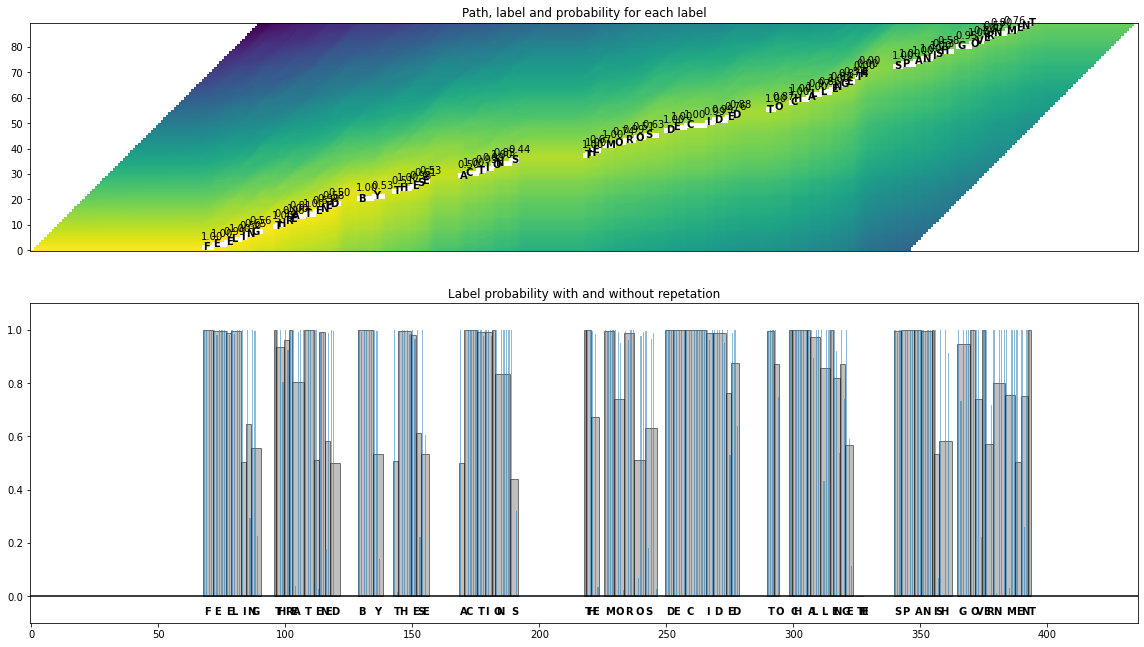

In [96]:
def plot_trellis_with_segments(trellis, segments, transcript):
    # To plot trellis with path, we take advantage of 'nan' value
    trellis_with_path = trellis.clone()
    for i, seg in enumerate(segments):
        if seg.label != "|":
            trellis_with_path[seg.start + 1 : seg.end + 1, i + 1] = float("nan")

    fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(16, 9.5))
    ax1.set_title("Path, label and probability for each label")
    ax1.imshow(trellis_with_path.T, origin="lower")
    ax1.set_xticks([])

    for i, seg in enumerate(segments):
        if seg.label != "|":
            ax1.annotate(seg.label, (seg.start + 0.7, i + 0.3), weight="bold")
            ax1.annotate(f"{seg.score:.2f}", (seg.start - 0.3, i + 4.3))

    ax2.set_title("Label probability with and without repetation")
    xs, hs, ws = [], [], []
    for seg in segments:
        if seg.label != "|":
            xs.append((seg.end + seg.start) / 2 + 0.4)
            hs.append(seg.score)
            ws.append(seg.end - seg.start)
            ax2.annotate(seg.label, (seg.start + 0.8, -0.07), weight="bold")
    ax2.bar(xs, hs, width=ws, color="gray", alpha=0.5, edgecolor="black")

    xs, hs = [], []
    for p in path:
        label = transcript[p.token_index]
        if label != "|":
            xs.append(p.time_index + 1)
            hs.append(p.score)

    ax2.bar(xs, hs, width=0.5, alpha=0.5)
    ax2.axhline(0, color="black")
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(-0.1, 1.1)


plot_trellis_with_segments(trellis, segments, transcript)
plt.tight_layout()
plt.show()

In [130]:
# Merge words
def merge_words(segments, separator="|"):
    words = []
    i1, i2 = 0, 0
    while i1 < len(segments):
        if i2 >= len(segments) or segments[i2].label == separator:
            if i1 != i2:
                segs = segments[i1:i2]
                word = "".join([seg.label for seg in segs])
                score = sum(seg.score * seg.length for seg in segs) / sum(seg.length for seg in segs)
                words.append(Segment(word, segments[i1].start, segments[i2 - 1].end, score))
            i1 = i2 + 1
            i2 = i1
        else:
            i2 += 1
    return words


word_segments = merge_words(segments)
# word_segment_list = [merge_words(segments) for segments in segment_list]
for word in word_segments:
    print(word)

In [137]:
word_segment_list[0][0]

FEELING	(0.46): [   38,    52)

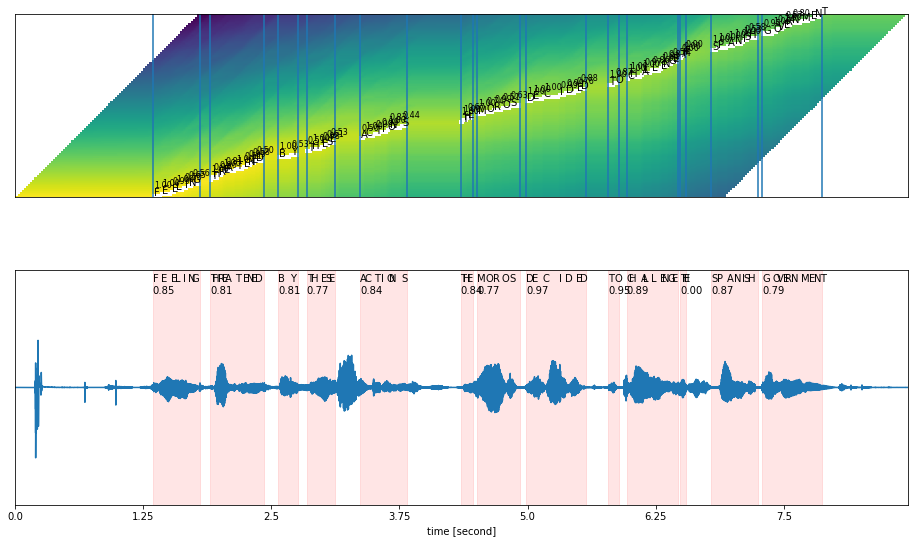

In [98]:
def plot_alignments(trellis, segments, word_segments, waveform):
    trellis_with_path = trellis.clone()
    for i, seg in enumerate(segments):
        if seg.label != "|":
            trellis_with_path[seg.start + 1 : seg.end + 1, i + 1] = float("nan")

    fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(16, 9.5))

    ax1.imshow(trellis_with_path[1:, 1:].T, origin="lower")
    ax1.set_xticks([])
    ax1.set_yticks([])

    for word in word_segments:
        ax1.axvline(word.start - 0.5)
        ax1.axvline(word.end - 0.5)

    for i, seg in enumerate(segments):
        if seg.label != "|":
            ax1.annotate(seg.label, (seg.start, i + 0.3))
            ax1.annotate(f"{seg.score:.2f}", (seg.start, i + 4), fontsize=8)

    # The original waveform
    ratio = waveform.size(0) / (trellis.size(0) - 1)
    ax2.plot(waveform)
    for word in word_segments:
        x0 = ratio * word.start
        x1 = ratio * word.end
        ax2.axvspan(x0, x1, alpha=0.1, color="red")
        ax2.annotate(f"{word.score:.2f}", (x0, 0.8))

    for seg in segments:
        if seg.label != "|":
            ax2.annotate(seg.label, (seg.start * ratio, 0.9))
    xticks = ax2.get_xticks()
    plt.xticks(xticks, xticks / bundle.sample_rate)
    ax2.set_xlabel("time [second]")
    ax2.set_yticks([])
    ax2.set_ylim(-1.0, 1.0)
    ax2.set_xlim(0, waveform.size(-1))


plot_alignments(
    trellis,
    segments,
    word_segments,
    waveform[0],
)
plt.show()

In [99]:
# A trick to embed the resulting audio to the generated file.
# `IPython.display.Audio` has to be the last call in a cell,
# and there should be only one call par cell.
def display_segment(i):
    ratio = waveform.size(1) / (trellis.size(0) - 1)
    word = word_segments[i]
    x0 = int(ratio * word.start)
    x1 = int(ratio * word.end)
    print(f"{word.label} ({word.score:.2f}): {x0 / bundle.sample_rate:.3f} - {x1 / bundle.sample_rate:.3f} sec")
    segment = waveform[:, x0:x1]
    return IPython.display.Audio(segment.numpy(), rate=bundle.sample_rate)

In [100]:
print(transcript)
IPython.display.Audio(SPEECH_FILE)

FEELING|THREATENED|BY|THESE|ACTIONS|THE|MOROS|DECIDED|TO|CHALLENGE|THE|SPANISH|GOVERNMENT


In [101]:
trellis.size()

torch.Size([436, 90])

In [102]:
display_segment(0)


FEELING (0.85): 1.342 - 1.802 sec


In [103]:
display_segment(1)


THREATENED (0.81): 1.903 - 2.423 sec


In [104]:
display_segment(2)


BY (0.81): 2.563 - 2.764 sec


In [105]:
display_segment(3)


THESE (0.77): 2.844 - 3.124 sec


In [106]:
display_segment(4)


ACTIONS (0.84): 3.365 - 3.825 sec


In [107]:
display_segment(5)


THE (0.84): 4.346 - 4.466 sec


In [108]:
display_segment(6)


MOROS (0.77): 4.506 - 4.927 sec


In [109]:
display_segment(7)


DECIDED (0.97): 4.987 - 5.568 sec


## Demo run over many files

In [112]:
import pandas as pd

In [113]:
pd_path = Path('/om2/data/public/mozilla-CommonVoice-9.0/cv-corpus-9.0-2022-04-27/en/')

# get manifest of all valid files:

tsv_path = pd_path / 'validated.tsv'

valid_df = pd.read_csv(tsv_path, sep='\t')
valid_df = valid_df[~pd.isna(valid_df.sentence)]
# valid_df = valid_df[~valid_df.gender.isna()]




In [219]:
valid_df.head()

,client_id,path,sentence,up_votes,down_votes,age,gender,accents,locale,segment
0,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,common_voice_en_27710027.mp3,"Joe Keaton disapproved of films, and Buster al...",3,1,NaN,NaN,NaN,en,NaN
1,0013037a1d45cc33460806cc3f8ecee9d536c45639ba4c...,common_voice_en_699711.mp3,She'll be all right.,2,1,NaN,NaN,NaN,en,NaN
2,0014c5a3e5715a54855257779b89c2bb498d470b225866...,common_voice_en_21953345.mp3,six,3,2,NaN,NaN,NaN,en,Benchmark
3,001509f4624a7dee75247f6a8b642c4a0d09f8be3eeea6...,common_voice_en_18132047.mp3,All's well that ends well.,2,0,NaN,NaN,NaN,en,NaN
4,001519f234e04528a2b36158c205dbe61c8da45ab0242f...,common_voice_en_27340672.mp3,It is a busy market town that serves a large s...,2,0,NaN,NaN,NaN,en,NaN


In [224]:
valid_df['index'] = valid_df.index

In [255]:
valid_df.shape[0]/100

15562.48

In [183]:
valid_meta = valid_df[['path', 'sentence']].to_dict('records')

In [145]:
f = cv_path / egs[0]
# f.with_suffix('.txt')

PosixPath('/scratch2/weka/mcdermott/imgriff/datasets/commonvoice_9/en/clips/common_voice_en_27710027.txt')

In [218]:
len(valid_meta)

1556248

In [ ]:
def get_transcript(transcript):
#     transcript = open(transcript_file, 'r').read()
    transcript = '|'.join([re.sub("[^\w\d'\s]+",'', word) for word in transcript.upper().split(' ')])
    return transcript
  
    
dictionary = {c: i for i, c in enumerate(labels)}

all_segs = []

model = model.cuda()
device='cuda'

with torch.inference_mode():
    
    for ix, example in tqdm(enumerate(valid_meta), len(valid_meta)):
        
        speech_file = cv_path / example['path']
        transcript = example['sentence']
        transcript = get_transcript(transcript)
        
        waveform, wav_sr = torchaudio.load(speech_file)
        waveform = resampler(waveform)
        emissions, _ = model(waveform.to(device))

        emissions = torch.log_softmax(emissions, dim=-1)
        emission = emissions[0].cpu().detach()
        
        tokens = [dictionary[c] for c in transcript]
        trellis = get_trellis(emission, tokens)
        path = backtrack(trellis, emission, tokens)
        segments = merge_repeats(path)
        word_segments = merge_words(segments)
        
        ratio = waveform.size(1) / (trellis.size(0) - 1)
        
        word_alignment = []
        for i in range(len(word_segments)):
            word = word_segments[i]
            x0 = int(ratio * word.start) /  bundle.sample_rate
            x1 = int(ratio * word.end) /  bundle.sample_rate
            word_alignment.append(Alignment(word.label, x0, x1, word.score))
        valid_meta[ix]['alignment'] = word_alignment
#             print(f"{word.label} ({word.score:.2f}): {x0 / bundle.sample_rate:.3f} - {x1 / bundle.sample_rate:.3f} sec")
#         print("\n")

In [ ]:
f"label: {all_segs[0][0].label}  start: {all_segs[0][0].start}  end: {all_segs[0][0].end}"

In [169]:
waveform.size(1), trellis.size(0)-1, ratio

(85824, 267, 321.438202247191)

In [172]:
word.start, x0/bundle.sample_rate

(176, 3.5358125)

In [213]:
pd.DataFrame.from_records(valid_meta[:10])['alignment'][0]

[JOE	(0.86): [0.76, 1.04),
 KEATON	(0.86): [1.06, 1.47),
 DISAPPROVED	(0.96): [1.51, 2.11),
 OF	(0.75): [2.19, 2.27),
 FILMS	(0.54): [2.37, 2.71),
 AND	(0.97): [2.81, 2.91),
 BUSTER	(0.83): [2.99, 3.37),
 ALSO	(0.99): [3.43, 3.65),
 HAD	(0.82): [3.71, 3.87),
 RESERVATIONS	(0.80): [3.92, 4.62),
 ABOUT	(0.91): [4.70, 4.94),
 THE	(0.84): [4.96, 5.06),
 MEDIUM	(0.94): [5.10, 5.40)]

In [257]:
cv_path.mkdir(parents=True, exist_ok=True)


In [270]:
f"{10:03}"

'010'

In [272]:
len(valid_meta)/100


15562.48